# Röntgenstrahlung



In [12]:
# Laden benötigter Bibliotheken
import pandas as pd
import numpy as np
import scipy.special as sc
import math
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Bestimmung der Totzeitkorrektur

An diesem Beispiel sehen Sie exemplarisch, wie Sie Daten einlesen, plotten und fitten können. Verwenden Sie dieses Beispiel für die Auswertung der übrigen Daten aus dem Versuch. Verwenden Sie Textboxen zur Dokumentation, was Sie gemacht haben. Dokumentieren Sie Ihren Quellcode!

### 1.1 Daten einlesen und plotten

In [13]:
#load data from file
data = pd.read_csv('Totzeit.txt', sep='\t')
data.head() # erste Zeilen zur Kontrolle anschauen

,Strom,Rate
0,0.01,242.8
1,0.02,503.2
2,0.03,722.1
3,0.04,947.3
4,0.05,1124.0


Schauen Sie sich die Datei Totzeit.txt an, um zu verstehen, wie Sie Ihre Messwerte speichern und einlesen können. In der Datei stehen keine Einheiten oder weitere Infos (außer den Spaltennamen)! Dokumentieren Sie daher alles in Ihrem Protokoll und in diesem Notebook!
Die obigen Daten wurden zum Beispiel mit folgenden Parametern aufgenommen:

$U=35\ kV$

$I$ in mA

Messzeit $15\ s$

mit 3mm Al-Filter

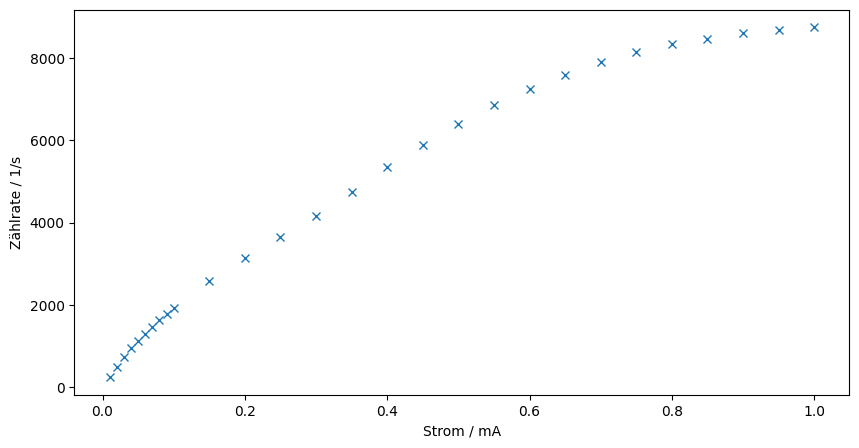

In [14]:
# plot data
fig, axs = plt.subplots(1, 1, figsize=(10, 5))
axs.plot(data['Strom'], data['Rate'], 'x', label='Zählrate 1/s')
axs.set_xlabel('Strom / mA')
axs.set_ylabel('Zählrate / 1/s')
plt.show()

### 1.2 Daten fitten und plotten

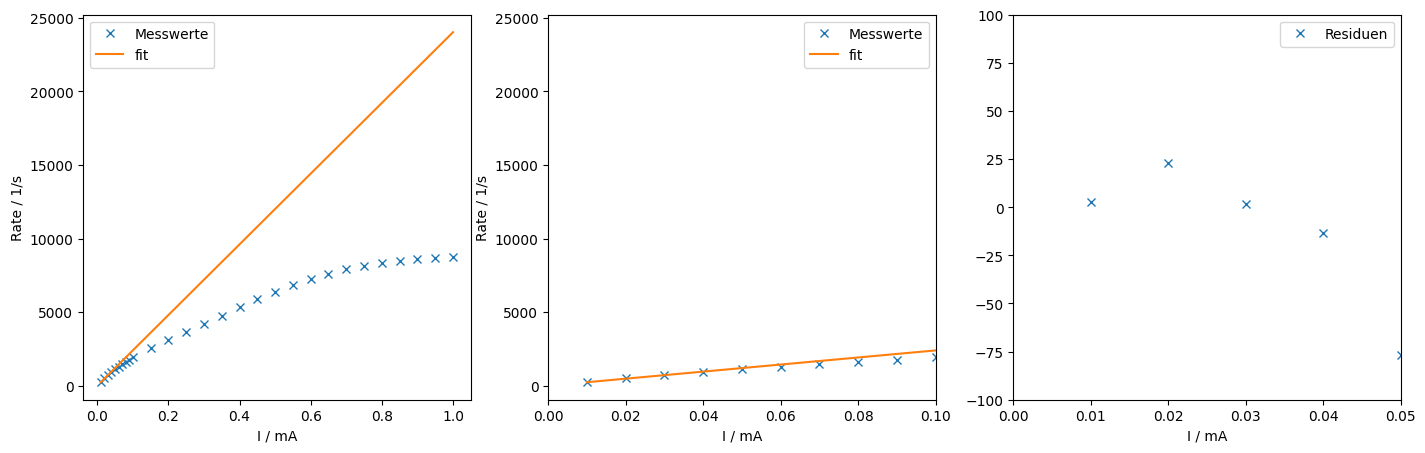

In [15]:
# define fit function
# die folgende Python-Funktion ist die Funktion, die Sie anfitten. Sie bekommt als Übergabewerte die
# Variable und sämtliche Konstanten übergeben und gibt den Funktionswert zurück.
def fitfunction(x, m):
    # Hier können auch andere mathematische Funktionen verwendet werden, z.B. np.exp(x) für die Exponentialfunktion
    return m*x

# Damit der Fit konvergiert, müssen Sie vermutlich sinnvolle Startwerte für die Parameter angeben.
# Starwerte werden als Array übergeben, wir haben hier aber nur eine Konstante, daher hat das Array nur einen Parameter.
## TODO: sinnvolle Startwerte überlegen und eintragen
initial_guess = [100]

#vielleicht wollen Sie nicht alle Daten fitten, sondern den Bereich einschränken. Wir wollen hier z.B. nur Ströme kleiner 
# 0.05 mA fitten
fitr = 0.05

# fit data
params, covariance = curve_fit(fitfunction,data.Strom[data.Strom < fitr], data.Rate[data.Strom < fitr], p0=initial_guess)

# plot data, fit and residuals 
fig, axs = plt.subplots(1, 3, figsize=(17, 5))
#Das Array axs enthält die drei Unterplots
#Dokumentation finden Sie unter https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.html, ist aber z.T. selbsterklärend
axs[0].plot(data['Strom'], data['Rate'], 'x', label='Messwerte')
axs[0].plot(data['Strom'], fitfunction(data['Strom'], params[0]), label='fit')
axs[1].plot(data['Strom'], data['Rate'], 'x', label='Messwerte')
axs[1].plot(data['Strom'], fitfunction(data['Strom'], params[0]), label='fit')
axs[2].plot(data['Strom'], data['Rate']-fitfunction(data['Strom'], params[0]), 'x', label='Residuen')
axs[2].set_xlabel('I / mA')
axs[0].set_xlabel('I / mA')
axs[0].set_ylabel('Rate / 1/s')
axs[0].legend()
axs[1].set_xlabel('I / mA')
axs[1].set_ylabel('Rate / 1/s')
axs[1].set_xbound(0, fitr+0.05)
axs[1].legend()
axs[2].legend()
axs[2].set_xbound(0, fitr)
axs[2].set_ybound(-100, 100)
plt.show()

Wir fitten hier die lineare Funktion $f(x)= m\cdot x$ (so lassen sich im Jupyter Notebook LaTeX Formeln darstellen). Sehen Fit und Residuendiagramm sinnvoll aus? Geben Sie ggf. einen anderen Fitbereich oder andere Startwerte an!


### 1.3 Bestimmung der Steigung aus dem Fit sowie der Unsicherheit


In [16]:
# wir schauen uns zunächst die Parameter und die Unsicherheiten aus dem Fit an:
# die Standardabweichungen erhalten wir aus der Wurzel der Diagonale der Kovarianzmatrix

print('Parameter: ', params)
perr = np.sqrt(np.diag(covariance))
print('Unsicherheiten: ', perr)

Parameter:  [24015.66666667]
Unsicherheiten:  [281.07801638]


In [17]:
# Steigung incl. Unsicherheit bestimmen

print("Steigung = ", params[0], " (1/s)/mA")
print("Unsicherheit = ", perr[0], " (1/s)/mA")

Steigung =  24015.666666666664  (1/s)/mA
Unsicherheit =  281.0780163785794  (1/s)/mA


## 5. Auswertung

### 5.1 Auswertung des Nulleffekts
Vor Durchführung der eigentlichen Messreihen wurde die natürliche Hintergrundstrahlung (Nulleffekt) bei abgeschalteter Röhrenspannung ($U = 0$ kV, $I = 0$ mA) über eine Messdauer von $\Delta t = 120$ s bestimmt.
Die Messung ergab eine mittlere Zählrate von:
$R_0 = 0,25$ s$^{-1}$

Um die Präzision der Auswertung zu wahren und systematische Fehler bei der Bestimmung des Schwächungskoeffizienten $\mu$ zu minimieren, wurde der Nulleffekt konsequent von allen nachfolgenden Messwerten abgezogen:
$R_{korr} = R_{mess} - R_0$

### 5.2 Absorption bei unterschiedlicher Dicke
In diesem Abschnitt wird die Abschwächung der Röntgenstrahlung durch Aluminium untersucht. Um die reine Materialabsorption zu isolieren, wurde von allen gemessenen Intensitäten zunächst der Nulleffekt $R_0 = 0,25$ s$^{-1}$ subtrahiert.

,Dicke x [mm],I_mess [1/s],I_korr [1/s],ln(I_korr)
0,0.0,786.60,786.35,6.6674
1,0.5,331.80,331.55,5.8038
2,1.0,146.70,146.45,4.9867
3,1.5,68.97,68.72,4.2300
4,2.0,31.10,30.85,3.4291
5,2.5,17.47,17.22,2.8461
6,3.0,9.00,8.75,2.1691


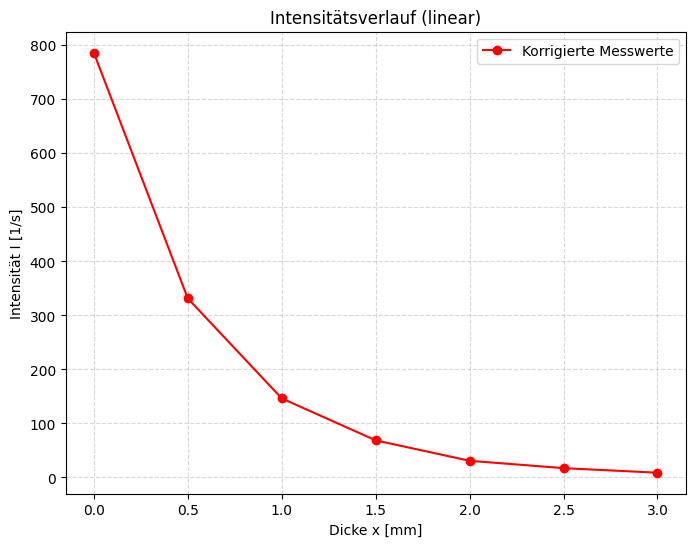

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Daten für 5.2 (Aluminium, 21 kV)
R_0 = 0.25
dicke_x = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
I_mess = np.array([786.60, 331.80, 146.70, 68.97, 31.10, 17.47, 9.00])
I_korr = I_mess - R_0
ln_I_korr = np.log(I_korr)

# DataFrame zur Darstellung
from IPython.display import display
df_5_2 = pd.DataFrame({
    'Dicke x [mm]': dicke_x,
    'I_mess [1/s]': I_mess,
    'I_korr [1/s]': I_korr,
    'ln(I_korr)': np.round(ln_I_korr, 4)
})
display(df_5_2)

# Plot Intensitätsverlauf (linear)
plt.figure(figsize=(8, 6))
plt.plot(dicke_x, I_korr, 'ro-', label='Korrigierte Messwerte')
plt.xlabel('Dicke x [mm]')
plt.ylabel('Intensität I [1/s]')
plt.title('Intensitätsverlauf (linear)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Bestimmung des Schwächungskoeffizienten $\mu$
Die theoretische Grundlage bildet das Lambert-Beer-Gesetz:
$I(x) = I_0 \cdot e^{-\mu \cdot x}$

Um den Schwächungskoeffizienten $\mu$ experimentell zu bestimmen, wird die Gleichung logarithmiert und damit linearisiert:
$\ln(I_{korr}) = -\mu \cdot x + \ln(I_0)$

Steigung m: -1.498 mm^-1
Schwächungskoeffizient mu: 1.498 mm^-1
Halbwertsschichtdicke d_1/2: 0.463 mm


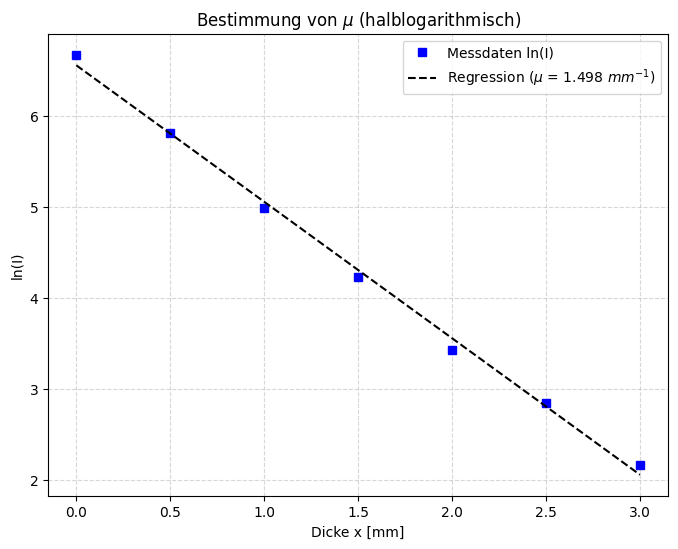

In [19]:
# Lineare Regression
def linear_func(x, m, b):
    return m * x + b

popt, pcov = curve_fit(linear_func, dicke_x, ln_I_korr)
m, b = popt
mu = -m

print(f"Steigung m: {m:.3f} mm^-1")
print(f"Schwächungskoeffizient mu: {mu:.3f} mm^-1")

# Halbwertsschichtdicke d_1/2 = ln(2) / mu
d_half = np.log(2) / mu
print(f"Halbwertsschichtdicke d_1/2: {d_half:.3f} mm")

# Plot Bestimmung von mu (halblogarithmisch)
plt.figure(figsize=(8, 6))
plt.plot(dicke_x, ln_I_korr, 'bs', label='Messdaten ln(I)')
plt.plot(dicke_x, linear_func(dicke_x, *popt), 'k--', label=f'Regression ($\\mu$ = {mu:.3f} $mm^{{-1}}$)')
plt.xlabel('Dicke x [mm]')
plt.ylabel('ln(I)')
plt.title('Bestimmung von $\\mu$ (halblogarithmisch)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### 5.3 Absorption verschiedener Materialien
In diesem Teil des Versuchs wurde untersucht, wie die Materialart bei identischer Geometrie und konstanter Röhrenspannung die Schwächung der Röntgenstrahlung beeinflusst.
Die Messungen erfolgten bei einer Schichtdicke von $d = 0,5$ mm und einer Röhrenspannung von $U = 21$ kV.

In [20]:
# Daten für 5.3
materialien = ['Luft', 'Kohlenstoff (C)', 'Aluminium (Al)', 'Eisen (Fe)', 'Kupfer (Cu)', 'Zirkonium (Zr)', 'Silber (Ag)']
Z_Werte = [7, 6, 13, 26, 29, 40, 47]
I_mess_5_3 = np.array([784.40, 764.00, 334.60, 0.23, 0.10, 2.20, 0.23])

# Wenn I_mess - R_0 <= 0 ist, verwenden wir 0.01 als Näherung, da ln(0) nicht definiert ist
I_korr_5_3 = np.where(I_mess_5_3 - R_0 <= 0, 0.01, I_mess_5_3 - R_0)

d = 0.5 # mm
I_Luft = I_korr_5_3[0]

mu_werte = -np.log(I_korr_5_3 / I_Luft) / d
mu_werte[0] = 0.000 # Für Luft manuell auf 0 setzen

df_5_3 = pd.DataFrame({
    'Material': materialien,
    'Z': Z_Werte,
    'I_mess [1/s]': I_mess_5_3,
    'I_korr [1/s]': I_korr_5_3,
    'mu [mm^-1]': np.round(mu_werte, 3)
})
from IPython.display import display
display(df_5_3)

,Material,Z,I_mess [1/s],I_korr [1/s],mu [mm^-1]
0,Luft,7,784.40,784.15,0.000
1,Kohlenstoff (C),6,764.00,763.75,0.053
2,Aluminium (Al),13,334.60,334.35,1.705
3,Eisen (Fe),26,0.23,0.01,22.540
4,Kupfer (Cu),29,0.10,0.01,22.540
5,Zirkonium (Zr),40,2.20,1.95,11.994
6,Silber (Ag),47,0.23,0.01,22.540


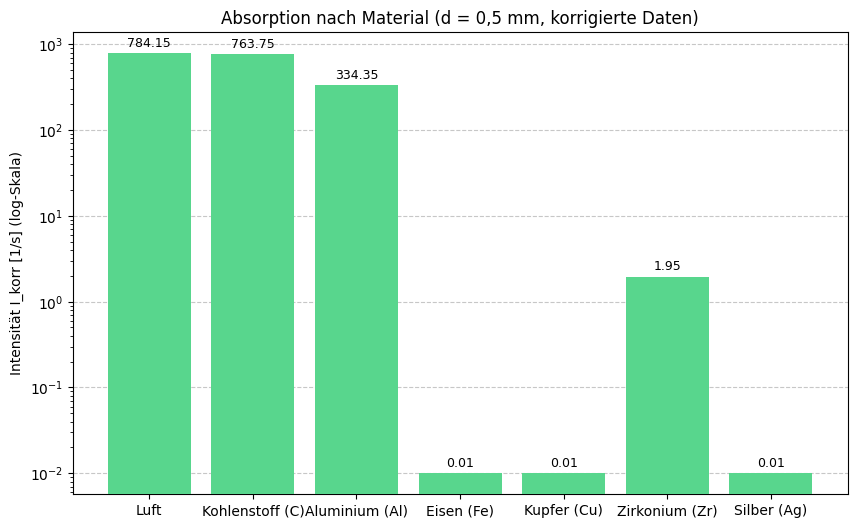

In [21]:
# Plot: Absorption nach Material (log-Skala)
plt.figure(figsize=(10, 6))
# Verwende log-Skala für die y-Achse
plt.bar(materialien, I_korr_5_3, color='#58D68D', zorder=3)
plt.yscale('log')
plt.ylabel('Intensität I_korr [1/s] (log-Skala)')
plt.title('Absorption nach Material (d = 0,5 mm, korrigierte Daten)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# Werte über den Balken anzeigen
for i, v in enumerate(I_korr_5_3):
    plt.text(i, v * 1.1, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

plt.show()

### Physikalische Interpretation der Ergebnisse

Die Messdaten zeigen eine starke Abhängigkeit der Absorption von der Ordnungszahl $Z$ des jeweiligen Materials. Dieses Verhalten lässt sich durch zwei wesentliche physikalische Effekte erklären.

#### Einfluss der Ordnungszahl Z
Bei der verwendeten Energie von 21 kV ist der Photoeffekt der dominierende Wechselwirkungsprozess zwischen Röntgenstrahlung und Materie.
Die Wahrscheinlichkeit $\tau$, dass ein Röntgenphoton absorbiert wird, steigt näherungsweise proportional zu $Z^4$ an. Dadurch besitzen Materialien mit hoher Ordnungszahl ein deutlich größeres Absorptionsvermögen.

**Leichte Elemente**
Materialien wie Luft oder Kohlenstoff besitzen nur kleine Ordnungszahlen ($Z \approx 6-7$). Ihre Atome enthalten vergleichsweise wenige Elektronen, wodurch die Wahrscheinlichkeit für eine Wechselwirkung mit der Strahlung gering bleibt. Die Röntgenstrahlung kann diese Materialien daher weitgehend ungehindert durchdringen.

**Schwere Metalle**
Schwere Metalle wie Eisen, Kupfer oder Silber besitzen eine deutlich höhere Elektronendichte und stärkere Kernladung. Dadurch steigt die Wahrscheinlichkeit für den Photoeffekt stark an.
Besonders Silber mit $Z = 47$ zeigt eine sehr starke Abschwächung der Strahlung. Die gemessene Intensität sinkt nahezu auf Null, was die hohe Wirksamkeit schwererer Elemente im Strahlenschutz verdeutlicht.

#### Die Zirkonium-Anomalie und die K-Absorptionskante
Ein auffälliges Ergebnis der Messreihe ist das Verhalten von Zirkonium. Trotz seiner hohen Ordnungszahl zeigt es eine größere Restintensität als theoretisch erwartet. Dieses Verhalten lässt sich durch die sogenannte K-Absorptionskante erklären.

Damit ein Röntgenphoton ein Elektron aus der innersten K-Schale eines Atoms herausschlagen kann, muss seine Energie größer sein als die Bindungsenergie dieses Elektrons.
Die K-Schalen-Bindungsenergie von Zirkonium liegt bei etwa:
$E_K \approx 18\text{ keV}$

Das verwendete Röntgenspektrum bei 21 kV enthält jedoch viele Photonen mit Energien unterhalb dieses Wertes. Diese Photonen besitzen nicht genügend Energie, um Elektronen aus der K-Schale des Zirkoniums herauszulösen. Für diesen Spektralbereich wird Zirkonium daher teilweise „transparent“.

Bei Eisen und Kupfer liegen die K-Absorptionskanten dagegen deutlich niedriger:
- Eisen: etwa 7,1 keV
- Kupfer: etwa 9,0 keV

Da nahezu das gesamte erzeugte Röntgenspektrum oberhalb dieser Energien liegt, können diese Materialien die Strahlung wesentlich effizienter absorbieren.

#### Zusammenfassung
Die Ergebnisse zeigen, dass die Absorption von Röntgenstrahlung im niedrigen Energiebereich stark von der Ordnungszahl des Materials abhängt. Materialien mit hoher Ordnungszahl absorbieren die Strahlung deutlich stärker als leichte Elemente.

Zusätzlich treten energieabhängige Transparenzeffekte auf, wenn die Photonenenergie unterhalb der Bindungsenergie innerer Elektronenschalen liegt. Diese sogenannten Absorptionskanten beeinflussen das Absorptionsverhalten erheblich und müssen bei der Auswahl geeigneter Abschirmmaterialien berücksichtigt werden.

## 5.4 Beugung von Röntgenstrahlung am NaCl-Einkristall
In diesem Versuchsabschnitt wird die Wellennatur der Röntgenstrahlung mithilfe der Beugung an einem NaCl-Einkristall untersucht. Ziel des Experiments ist die Aufnahme des Röntgenspektrums sowie die experimentelle Bestimmung charakteristischer Wellenlängen der erzeugten Strahlung.

### Versuchsprinzip und Bragg-Bedingung
Die Beugung der Röntgenstrahlung erfolgt nach dem Prinzip der Bragg-Reflexion. Treffen die Röntgenstrahlen unter dem Glanzwinkel $\theta$ auf die Netzebenen des Kristalls, so entsteht konstruktive Interferenz, wenn der Gangunterschied einem ganzzahligen Vielfachen der Wellenlänge $\lambda$ entspricht.

Die Bedingung hierfür wird durch die Bragg-Gleichung beschrieben:
$n \cdot \lambda = 2 \cdot d \cdot \sin(\theta)$

Dabei gilt:
- $d = 282,01\text{ pm}$ als Netzebenenabstand des NaCl-Kristalls,
- $n$ als Beugungsordnung,
- $\lambda$ als Wellenlänge der Röntgenstrahlung,
- $\theta$ als Glanzwinkel.

Nur wenn diese Bedingung erfüllt ist, entstehen Intensitätsmaxima im gemessenen Spektrum.

### Physikalische Analyse des Beugungsspektrums
Die grafische Darstellung der Zählrate in Abhängigkeit vom Glanzwinkel $\theta$ zeigt eine klare Trennung zwischen kontinuierlichem Untergrund und charakteristischen Peaks der Molybdän-Anode.

**Kontinuierliches Bremsstrahlungsspektrum (Bremsberg)**
Das kontinuierliche Spektrum entsteht durch die Abbremsung der Elektronen im Coulombfeld der Anode. Dabei wird kinetische Energie in Röntgenstrahlung umgewandelt.
Der steile Anstieg der Intensität bei kleinen Winkeln (ca. 4,5° bis 5,0°) entspricht der Grenzwellenlänge $\lambda_{min}$. Unterhalb dieser Wellenlänge ist keine Emission mehr möglich, da die Elektronenenergie vollständig ausgeschöpft wäre.

**Charakteristische Linien ($K_\alpha$ und $K_\beta$)**
Die scharfen Intensitätsmaxima im Spektrum sind die charakteristischen Linien der Molybdän-Anode.

Dabei gilt:
- $K_\alpha$-Linie: höhere Intensität
- $K_\beta$-Linie: geringere Intensität

Die höhere Intensität der $K_\alpha$-Linie ergibt sich aus der größeren Übergangswahrscheinlichkeit innerhalb der Elektronenhülle.

### Charakteristische Kennlinien (Messdatentabelle und Peak-Identifikation)
Die folgende Tabelle zeigt die gemessenen Glanzwinkel der wichtigsten Intensitätsmaxima sowie deren Zuordnung zu den charakteristischen Spektrallinien.

In [22]:
# Charakteristische Kennlinien
data_5_4 = {
    'Beugungsordnung (n)': [1, 1, 2, 2],
    'Linie': ['K_beta', 'K_alpha', 'K_beta', 'K_alpha'],
    'Glanzwinkel theta [°]': [6.3, 7.2, 12.8, 14.4],
    'Zählrate R [1/s]': [361.3, 420.0, 140.0, 160.0]
}

df_5_4 = pd.DataFrame(data_5_4)
from IPython.display import display
display(df_5_4)

,Beugungsordnung (n),Linie,Glanzwinkel theta [°],Zählrate R [1/s]
0,1,K_beta,6.3,361.3
1,1,K_alpha,7.2,420.0
2,2,K_beta,12.8,140.0
3,2,K_alpha,14.4,160.0


### Interpretation der Ergebnisse
Die Messdaten weisen insgesamt eine hohe Qualität und gute Übereinstimmung mit der Theorie auf.

**Wellenlängenbestimmung**
Über die gemessenen Glanzwinkel kann mithilfe der Bragg-Gleichung die Wellenlänge der Molybdän-Strahlung experimentell bestimmt werden.
Ein Vergleich der $K_\alpha$-Linie mit dem Literaturwert von etwa
$\lambda \approx 71\text{ pm}$
dient dabei zur Validierung der Messgenauigkeit und zeigt eine gute Übereinstimmung zwischen Theorie und Experiment.

**Apparative Auflösung**
Die deutliche und scharfe Auflösung der Beugung in zweiter Ordnung belegt die hohe Qualität der Messapparatur.
Insbesondere zeigt dies die sehr gute Justage des Röntgengoniometers sowie die hohe Güte des verwendeten NaCl-Einkristalls.

**Konsistenz der Messdaten**
Die Lage der Peaks in erster und zweiter Beugungsordnung steht in direktem Einklang mit der theoretischen Erwartung der Bragg-Bedingung.
Insbesondere folgt das Verhältnis der Winkel für $n = 1$ und $n = 2$ der sinusabhängigen Struktur der Bragg-Gleichung exakt, was die Gültigkeit des zugrunde liegenden Modells für diesen Versuchsaufbau bestätigt.